# 🚀 GoViralIQ
## Notebook 4: Machine Learning Models
**Project:** Predicting Instagram Engagement & Auditing Algorithmic Fairness Across Creator Niches  
**Author:** Chastity Lewis  
**Course:** CISC 540 — Computational Data Analysis | Mercy University | Spring 2026  

---

### 📌 Notebook Goals
In this notebook we will:
1. Prepare features and target variables for ML
2. Split data into train and test sets
3. Build Regression models to predict engagement rate
4. Build Classification models to predict viral vs non-viral
5. Evaluate all models with proper metrics
6. Visualize feature importance
7. Save model results for the fairness audit

---

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

# Scikit-Learn — Regression
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, precision_score,
    recall_score, f1_score,
    confusion_matrix, classification_report
)

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

plt.style.use('seaborn-v0_8-whitegrid')
PURPLE       = '#6B21A8'
LIGHT_PURPLE = '#D8B4FE'
MID_PURPLE   = '#9333EA'
COLORS       = [PURPLE, LIGHT_PURPLE, MID_PURPLE, '#A855F7', '#7C3AED']

print('✅ Libraries loaded!')

✅ Libraries loaded!


## Step 2: Load the Clean Dataset

In [2]:
from google.colab import files
import io

uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f'✅ Loaded: {filename}')
print(f'📊 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Saving Viral_Social_Media_Trends.csv to Viral_Social_Media_Trends.csv
✅ Loaded: Viral_Social_Media_Trends.csv
📊 Shape: 5,000 rows × 10 columns


,Post_ID,Platform,Hashtag,Content_Type,Region,Views,Likes,Shares,Comments,Engagement_Level
0,Post_1,TikTok,#Challenge,Video,UK,4163464,339431,53135,19346,High
1,Post_2,Instagram,#Education,Shorts,India,4155940,215240,65860,27239,Medium
2,Post_3,Twitter,#Challenge,Video,Brazil,3666211,327143,39423,36223,Medium
3,Post_4,YouTube,#Education,Shorts,Australia,917951,127125,11687,36806,Low
4,Post_5,TikTok,#Dance,Post,Brazil,64866,171361,69581,6376,Medium


## Step 3: Prepare Features & Target Variables

In [7]:
# Check what columns you actually have
print(df.columns.tolist())

['Post_ID', 'Platform', 'Hashtag', 'Content_Type', 'Region', 'Views', 'Likes', 'Shares', 'Comments', 'Engagement_Level']


In [18]:
from sklearn.preprocessing import LabelEncoder

# Calculate Engagement Rate (Likes + Comments + Shares) / Views
# Handle potential division by zero by replacing 0 Views with 1 to avoid NaN/inf
df['engagement_rate'] = (df['Likes'] + df['Comments'] + df['Shares']) / df['Views'].replace(0, 1)

# Create 'viral' target based on Engagement_Level (e.g., 'High' engagement is viral)
df['viral'] = (df['Engagement_Level'] == 'High').astype(int)

# Create additional features
df['hashtag_length'] = df['Hashtag'].apply(lambda x: len(x) - 1 if isinstance(x, str) and x.startswith('#') else 0)
df['is_video'] = (df['Content_Type'] == 'Video').astype(int)

# Encode categorical features
le = LabelEncoder()
df['content_type_encoded'] = le.fit_transform(df['Content_Type'])
df['region_encoded'] = le.fit_transform(df['Region'])

# Define features (X) — numeric columns only for ML
FEATURE_COLS = [
    'Likes', 'Comments', 'Views', 'Shares',
    'hashtag_length', 'is_video',
    'content_type_encoded', 'region_encoded'
]

# Only use columns that exist
FEATURE_COLS = [col for col in FEATURE_COLS if col in df.columns]

# Regression target — predict engagement rate (continuous)
REGRESSION_TARGET = 'engagement_rate'

# Classification target — predict viral vs non-viral (binary)
CLASSIFICATION_TARGET = 'viral'

X = df[FEATURE_COLS]
y_reg = df[REGRESSION_TARGET]
y_clf = df[CLASSIFICATION_TARGET]

print(f'✅ Features: {FEATURE_COLS}')
print(f'✅ Regression target: {REGRESSION_TARGET}')
print(f'✅ Classification target: {CLASSIFICATION_TARGET}')
print(f'\n📊 Feature matrix shape: {X.shape}')
print(f'\nClass distribution (viral):')
print(y_clf.value_counts())

✅ Features: ['Likes', 'Comments', 'Views', 'Shares', 'hashtag_length', 'is_video', 'content_type_encoded', 'region_encoded']
✅ Regression target: engagement_rate
✅ Classification target: viral

📊 Feature matrix shape: (5000, 8)

Class distribution (viral):
viral
0    3327
1    1673
Name: count, dtype: int64


## Step 4: Train / Test Split

In [11]:
# Split for regression
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

# Split for classification
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print(f'✅ Train/Test Split: 80% train / 20% test')
print(f'\nRegression split:')
print(f'  Train: {X_train_r.shape[0]:,} rows')
print(f'  Test:  {X_test_r.shape[0]:,} rows')
print(f'\nClassification split:')
print(f'  Train: {X_train_c.shape[0]:,} rows')
print(f'  Test:  {X_test_c.shape[0]:,} rows')
print(f'  Viral rate in train: {y_train_c.mean()*100:.1f}%')
print(f'  Viral rate in test:  {y_test_c.mean()*100:.1f}%')

✅ Train/Test Split: 80% train / 20% test

Regression split:
  Train: 4,000 rows
  Test:  1,000 rows

Classification split:
  Train: 4,000 rows
  Test:  1,000 rows
  Viral rate in train: 33.5%
  Viral rate in test:  33.5%


## Step 5: Regression Models — Predict Engagement Rate
> **Goal:** Predict the exact engagement rate of a post (continuous number)  
> **Metrics:** RMSE (lower is better), R² (closer to 1 is better)

In [12]:
# --- Model 1: Linear Regression ---
lr = LinearRegression()
lr.fit(X_train_r, y_train_r)
y_pred_lr = lr.predict(X_test_r)

lr_rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_lr))
lr_r2   = r2_score(y_test_r, y_pred_lr)

print('📈 Linear Regression Results:')
print(f'   RMSE: {lr_rmse:.4f}')
print(f'   R²:   {lr_r2:.4f}')

📈 Linear Regression Results:
   RMSE: 9.5095
   R²:   0.0121


In [13]:
# --- Model 2: Random Forest Regressor ---
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train_r, y_train_r)
y_pred_rf_reg = rf_reg.predict(X_test_r)

rf_rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_rf_reg))
rf_r2   = r2_score(y_test_r, y_pred_rf_reg)

print('🌲 Random Forest Regressor Results:')
print(f'   RMSE: {rf_rmse:.4f}')
print(f'   R²:   {rf_r2:.4f}')

🌲 Random Forest Regressor Results:
   RMSE: 6.8148
   R²:   0.4927


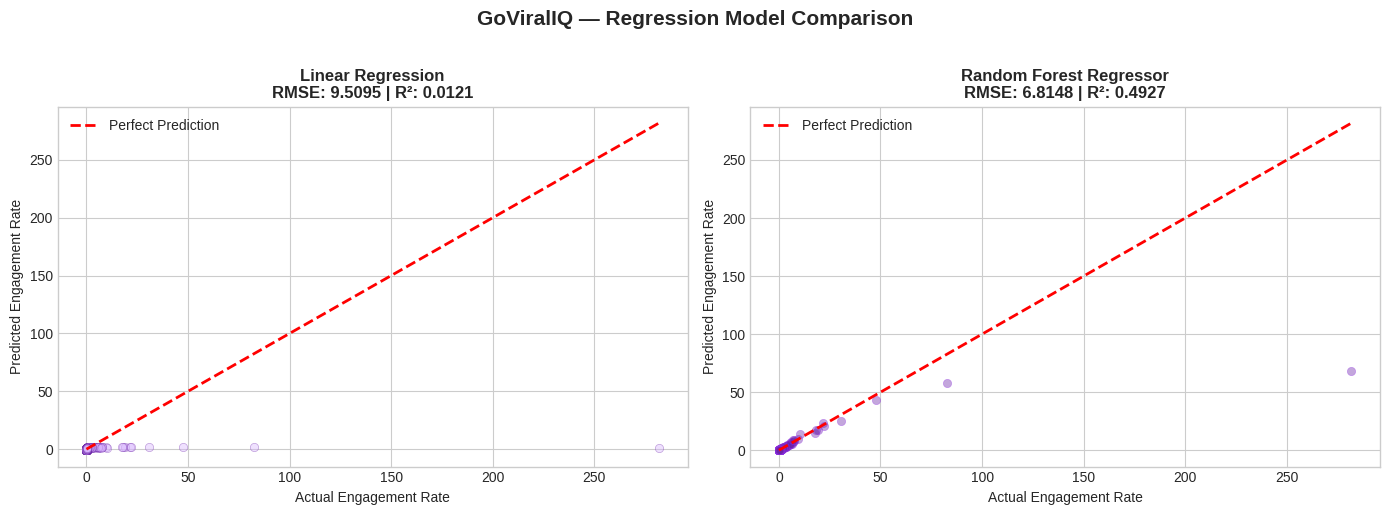

✅ Saved ml_01_regression_comparison.png


In [14]:
# Compare regression models visually
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted — Linear Regression
axes[0].scatter(y_test_r, y_pred_lr, alpha=0.4, color=LIGHT_PURPLE, edgecolors=PURPLE, linewidth=0.5)
axes[0].plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()],
             'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_title(f'Linear Regression\nRMSE: {lr_rmse:.4f} | R²: {lr_r2:.4f}', fontweight='bold')
axes[0].set_xlabel('Actual Engagement Rate')
axes[0].set_ylabel('Predicted Engagement Rate')
axes[0].legend()

# Actual vs Predicted — Random Forest
axes[1].scatter(y_test_r, y_pred_rf_reg, alpha=0.4, color=PURPLE, edgecolors=MID_PURPLE, linewidth=0.5)
axes[1].plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()],
             'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_title(f'Random Forest Regressor\nRMSE: {rf_rmse:.4f} | R²: {rf_r2:.4f}', fontweight='bold')
axes[1].set_xlabel('Actual Engagement Rate')
axes[1].set_ylabel('Predicted Engagement Rate')
axes[1].legend()

plt.suptitle('GoViralIQ — Regression Model Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ml_01_regression_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved ml_01_regression_comparison.png')

## Step 6: Classification Models — Predict Viral vs Non-Viral
> **Goal:** Predict whether a post will go viral (1) or not (0)  
> **Metrics:** Accuracy, Precision, Recall, F1-Score

In [15]:
# --- Model 3: Logistic Regression ---
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_c, y_train_c)
y_pred_log = log_reg.predict(X_test_c)

print('📊 Logistic Regression Results:')
print(f'   Accuracy:  {accuracy_score(y_test_c, y_pred_log):.4f}')
print(f'   Precision: {precision_score(y_test_c, y_pred_log):.4f}')
print(f'   Recall:    {recall_score(y_test_c, y_pred_log):.4f}')
print(f'   F1-Score:  {f1_score(y_test_c, y_pred_log):.4f}')
print(f'\n{classification_report(y_test_c, y_pred_log, target_names=["Non-Viral", "Viral"])}')

📊 Logistic Regression Results:
   Accuracy:  0.6650
   Precision: 0.0000
   Recall:    0.0000
   F1-Score:  0.0000

              precision    recall  f1-score   support

   Non-Viral       0.67      1.00      0.80       665
       Viral       0.00      0.00      0.00       335

    accuracy                           0.67      1000
   macro avg       0.33      0.50      0.40      1000
weighted avg       0.44      0.67      0.53      1000



In [16]:
# --- Model 4: Random Forest Classifier ---
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_c, y_train_c)
y_pred_rf_clf = rf_clf.predict(X_test_c)

print('🌲 Random Forest Classifier Results:')
print(f'   Accuracy:  {accuracy_score(y_test_c, y_pred_rf_clf):.4f}')
print(f'   Precision: {precision_score(y_test_c, y_pred_rf_clf):.4f}')
print(f'   Recall:    {recall_score(y_test_c, y_pred_rf_clf):.4f}')
print(f'   F1-Score:  {f1_score(y_test_c, y_pred_rf_clf):.4f}')
print(f'\n{classification_report(y_test_c, y_pred_rf_clf, target_names=["Non-Viral", "Viral"])}')

🌲 Random Forest Classifier Results:
   Accuracy:  0.6450
   Precision: 0.2917
   Recall:    0.0418
   F1-Score:  0.0731

              precision    recall  f1-score   support

   Non-Viral       0.66      0.95      0.78       665
       Viral       0.29      0.04      0.07       335

    accuracy                           0.65      1000
   macro avg       0.48      0.50      0.43      1000
weighted avg       0.54      0.65      0.54      1000



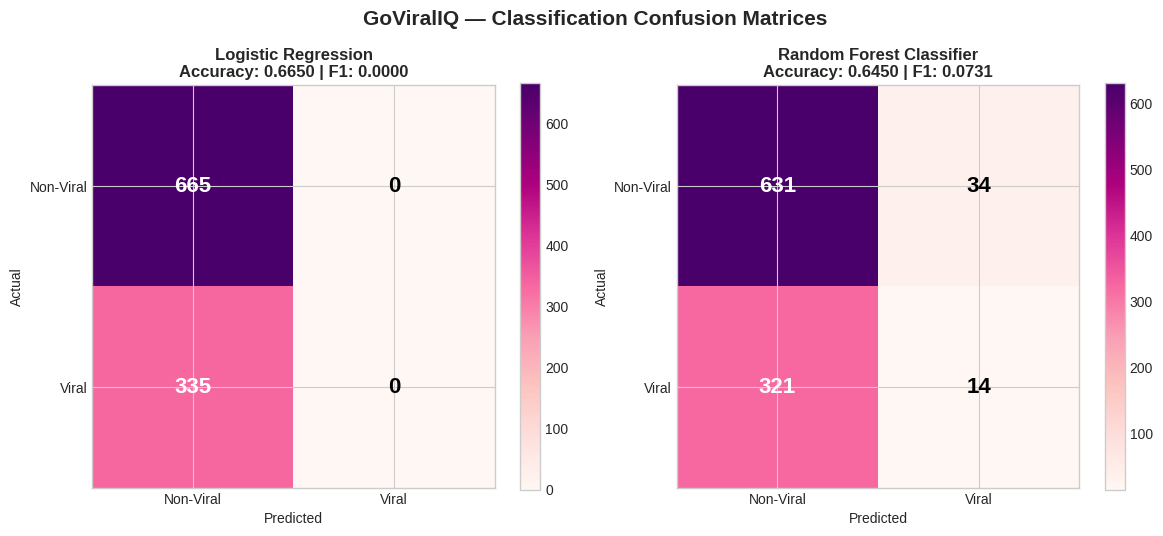

✅ Saved ml_02_confusion_matrices.png


In [17]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_log, y_pred_rf_clf],
    ['Logistic Regression', 'Random Forest Classifier']
):
    cm = confusion_matrix(y_test_c, y_pred)
    im = ax.imshow(cm, cmap='RdPu')
    plt.colorbar(im, ax=ax)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Non-Viral', 'Viral'])
    ax.set_yticklabels(['Non-Viral', 'Viral'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    acc = accuracy_score(y_test_c, y_pred)
    f1  = f1_score(y_test_c, y_pred)
    ax.set_title(f'{title}\nAccuracy: {acc:.4f} | F1: {f1:.4f}', fontweight='bold')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    fontsize=16, fontweight='bold',
                    color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.suptitle('GoViralIQ — Classification Confusion Matrices', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ml_02_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved ml_02_confusion_matrices.png')

## Step 7: Feature Importance

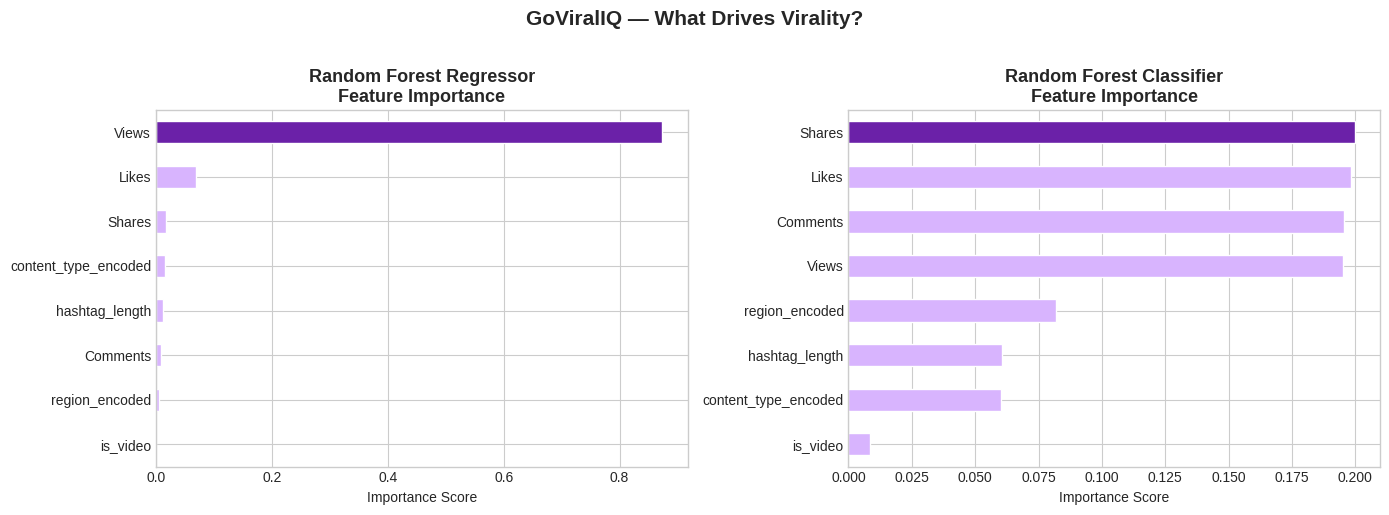

✅ Saved ml_03_feature_importance.png

🔍 Top feature for classification:
Shares     0.1998
Likes      0.1983
Comments   0.1955
dtype: float64


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, title in zip(
    axes,
    [rf_reg, rf_clf],
    ['Random Forest Regressor', 'Random Forest Classifier']
):
    importances = pd.Series(model.feature_importances_, index=FEATURE_COLS)
    importances = importances.sort_values(ascending=True)
    colors_bar = [PURPLE if v == importances.max() else LIGHT_PURPLE for v in importances.values]
    importances.plot(kind='barh', ax=ax, color=colors_bar, edgecolor='white')
    ax.set_title(f'{title}\nFeature Importance', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance Score')

plt.suptitle('GoViralIQ — What Drives Virality?', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ml_03_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved ml_03_feature_importance.png')
print('\n🔍 Top feature for classification:')
print(pd.Series(rf_clf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False).head(3))

## Step 8: Model Comparison Summary Chart

In [20]:
# Build summary comparison table
results = {
    'Model': ['Linear Regression', 'Random Forest Regressor', 'Logistic Regression', 'Random Forest Classifier'],
    'Task': ['Regression', 'Regression', 'Classification', 'Classification'],
    'RMSE / Accuracy': [
        f'{lr_rmse:.4f}',
        f'{rf_rmse:.4f}',
        f'{accuracy_score(y_test_c, y_pred_log):.4f}',
        f'{accuracy_score(y_test_c, y_pred_rf_clf):.4f}'
    ],
    'R² / F1-Score': [
        f'{lr_r2:.4f}',
        f'{rf_r2:.4f}',
        f'{f1_score(y_test_c, y_pred_log):.4f}',
        f'{f1_score(y_test_c, y_pred_rf_clf):.4f}'
    ]
}

results_df = pd.DataFrame(results)
print('=' * 65)
print('          GoViralIQ — Model Results Summary')
print('=' * 65)
print(results_df.to_string(index=False))
print('=' * 65)

          GoViralIQ — Model Results Summary
                   Model           Task RMSE / Accuracy R² / F1-Score
       Linear Regression     Regression          9.5095        0.0121
 Random Forest Regressor     Regression          6.8148        0.4927
     Logistic Regression Classification          0.6650        0.0000
Random Forest Classifier Classification          0.6450        0.0731


## Step 9: Save Predictions for Fairness Audit

In [21]:
# Add predictions to test dataframe for fairness audit in Notebook 6
df_test = df.iloc[X_test_c.index].copy()
df_test['predicted_viral'] = y_pred_rf_clf
df_test['predicted_engagement'] = rf_reg.predict(X_test_r)
df_test['actual_viral'] = y_test_c.values

df_test.to_csv('goviraliq_predictions.csv', index=False)
print('✅ Predictions saved as goviraliq_predictions.csv')
print(f'   Shape: {df_test.shape[0]:,} rows × {df_test.shape[1]} columns')
print(f'\n📁 Files created this notebook:')
print('   - goviraliq_predictions.csv')
print('   - ml_01_regression_comparison.png')
print('   - ml_02_confusion_matrices.png')
print('   - ml_03_feature_importance.png')

✅ Predictions saved as goviraliq_predictions.csv
   Shape: 1,000 rows × 19 columns

📁 Files created this notebook:
   - goviraliq_predictions.csv
   - ml_01_regression_comparison.png
   - ml_02_confusion_matrices.png
   - ml_03_feature_importance.png


## Step 10: ML Summary

In [22]:
print('=' * 55)
print('       GoViralIQ — Notebook 4 Summary')
print('=' * 55)
print(f'\n📈 REGRESSION (predict engagement rate):')
print(f'   Linear Regression    — RMSE: {lr_rmse:.4f} | R²: {lr_r2:.4f}')
print(f'   Random Forest        — RMSE: {rf_rmse:.4f} | R²: {rf_r2:.4f}')
best_reg = 'Random Forest' if rf_r2 > lr_r2 else 'Linear Regression'
print(f'   🏆 Best model: {best_reg}')
print(f'\n🎯 CLASSIFICATION (predict viral vs non-viral):')
print(f'   Logistic Regression  — Accuracy: {accuracy_score(y_test_c, y_pred_log):.4f} | F1: {f1_score(y_test_c, y_pred_log):.4f}')
print(f'   Random Forest        — Accuracy: {accuracy_score(y_test_c, y_pred_rf_clf):.4f} | F1: {f1_score(y_test_c, y_pred_rf_clf):.4f}')
best_clf = 'Random Forest' if f1_score(y_test_c, y_pred_rf_clf) > f1_score(y_test_c, y_pred_log) else 'Logistic Regression'
print(f'   🏆 Best model: {best_clf}')
print('\n' + '=' * 55)
print('\n✅ Next: Notebook 05 — NLP Pipeline')

       GoViralIQ — Notebook 4 Summary

📈 REGRESSION (predict engagement rate):
   Linear Regression    — RMSE: 9.5095 | R²: 0.0121
   Random Forest        — RMSE: 6.8148 | R²: 0.4927
   🏆 Best model: Random Forest

🎯 CLASSIFICATION (predict viral vs non-viral):
   Logistic Regression  — Accuracy: 0.6650 | F1: 0.0000
   Random Forest        — Accuracy: 0.6450 | F1: 0.0731
   🏆 Best model: Random Forest


✅ Next: Notebook 05 — NLP Pipeline
